In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional-looking plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

In [61]:
file_path = "/Users/deepak/Desktop/Datathon/data/raw/Road.csv"
df = pd.read_csv(file_path)

print(f"Original Dataset Shape: {df.shape}")
df.head()

Original Dataset Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## Basic Inspection

In [62]:
# Info (Data types and non-null counts)
df.info()

# 3. Describe (Basic statistics)
print("--- Statistical Summary (Including Categoricals) ---")
display(df.describe(include='all').T.head(10)) # Displaying first 10 for readability

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,12316,1074,15:30:00,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,12316,7,Friday,2041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_band_of_driver,12316,5,18-30,4271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex_of_driver,12316,3,Male,11437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Educational_level,11575,7,Junior high school,7619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_driver_relation,11737,4,Employee,9627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driving_experience,11487,7,5-10yr,3363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type_of_vehicle,11366,17,Automobile,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_of_vehicle,11834,4,Owner,10459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Service_year_of_vehicle,8388,6,Unknown,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Variable Analysis

In [63]:
# 1. Distribution & Class Imbalance (Exact Percentages)
target_col = 'Accident_severity'
target_counts = df[target_col].value_counts()
target_percentages = df[target_col].value_counts(normalize=True) * 100

target_stats = pd.DataFrame({
    'Count': target_counts, 
    'Percentage (%)': target_percentages.round(2)
})
display(target_stats)

,Count,Percentage (%)
Accident_severity,,
Slight Injury,10415,84.56
Serious Injury,1743,14.15
Fatal injury,158,1.28


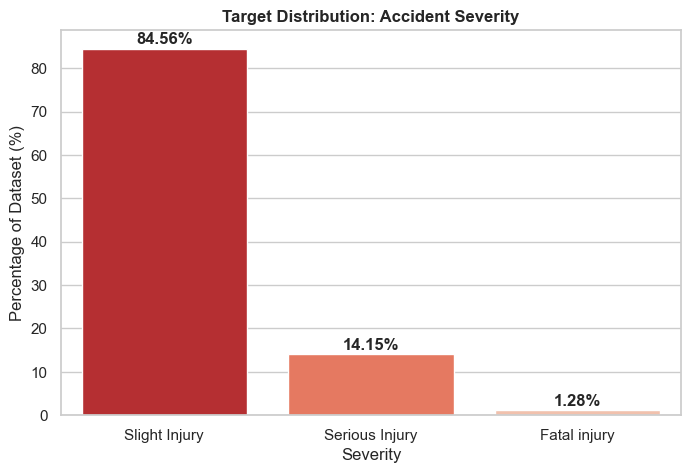

In [64]:
# 2. Visualizing the Imbalance
plt.figure(figsize=(8, 5))
sns.barplot(x=target_stats.index, y=target_stats['Percentage (%)'], palette='Reds_r')
plt.title('Target Distribution: Accident Severity', fontweight='bold')
plt.ylabel('Percentage of Dataset (%)')
plt.xlabel('Severity')
for i, v in enumerate(target_stats['Percentage (%)']):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.show()

## Standardize Missing Values

In [65]:
# The dataset uses text to represent missing data. We need these to be np.nan
missing_formats = ['na', 'Unknown', ' ', '', 'nan']
df.replace(missing_formats, np.nan, inplace=True)

# Calculate percentage of missing values per column
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Percentage': missing_percentages})

# Calculate missing values (count + percentage)
missing_counts = df.isnull().sum()
missing_percentages = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_percentages
})

print("\nTop 10 Columns with Missing Values:")
print(missing_df.sort_values(by='Missing_Percentage', ascending=False).head(10))


Top 10 Columns with Missing Values:
                         Missing_Count  Missing_Percentage
Service_year_of_vehicle           6811           55.302046
Age_band_of_casualty              4443           36.075024
Casualty_class                    4443           36.075024
Sex_of_casualty                   4443           36.075024
Casualty_severity                 4443           36.075024
Defect_of_vehicle                 4427           35.945112
Work_of_casuality                 3217           26.120494
Fitness_of_casuality              2635           21.394933
Age_band_of_driver                1548           12.569016
Types_of_Junction                 1078            8.752842


## Time Feature Engineering

In [66]:
# Convert Time column to datetime, extract the hour
df['Hour_of_Day'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

# Create a logical 'Time_of_Day' category
def categorize_time(hour):
    if pd.isna(hour):
        return np.nan
    elif 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour_of_Day'].apply(categorize_time)

print("Time features successfully engineered.")
df[['Time', 'Hour_of_Day', 'Time_of_Day']].head()

Time features successfully engineered.


,Time,Hour_of_Day,Time_of_Day
0,17:02:00,17,Evening
1,17:02:00,17,Evening
2,17:02:00,17,Evening
3,1:06:00,1,Night
4,1:06:00,1,Night


## Duplicate and Numeric Analysis

STEP 4: FINAL BASIC CLEANING (Duplicates)
Duplicate rows found: 0
No duplicates found. Data is clean.

STEP 5 & 6: UNIVARIATE & BIVARIATE ANALYSIS (Numeric Columns)


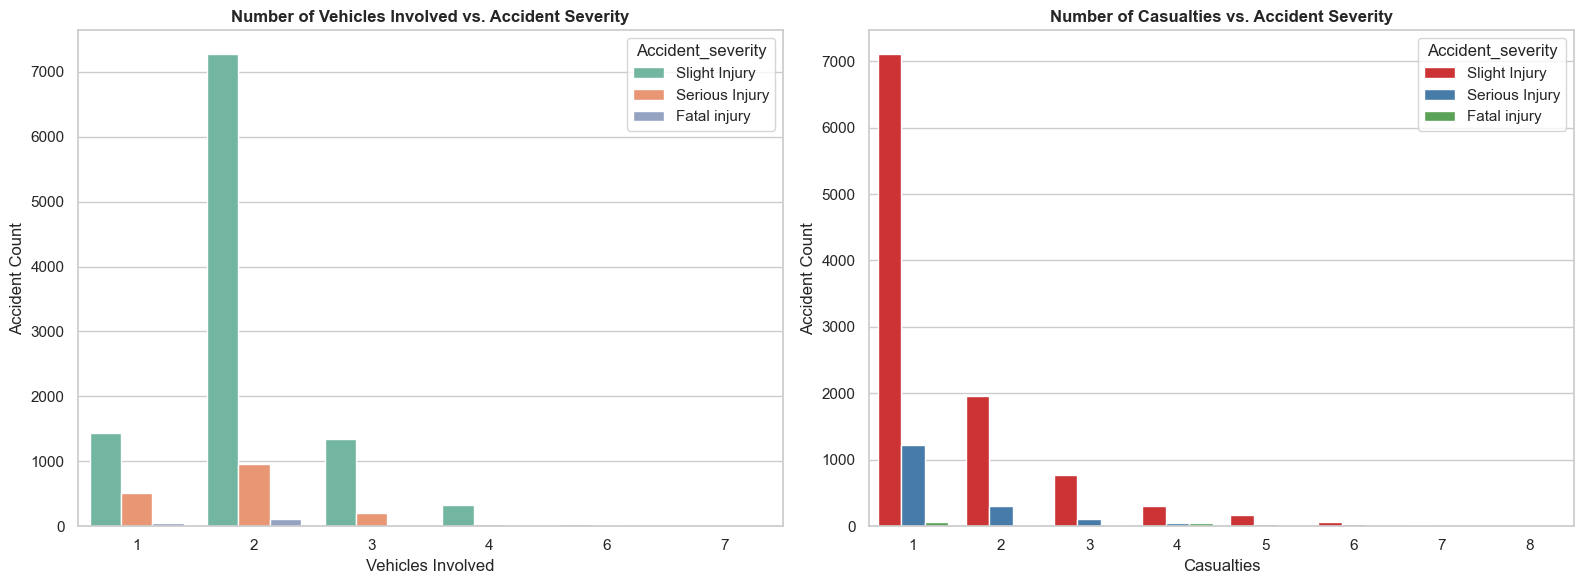

In [67]:
print("="*50)
print("STEP 4: FINAL BASIC CLEANING (Duplicates)")
print("="*50)

# Check for identical rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

# Drop them if they exist
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Dropped {duplicate_count} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found. Data is clean.")

print("\n" + "="*50)
print("STEP 5 & 6: UNIVARIATE & BIVARIATE ANALYSIS (Numeric Columns)")
print("="*50)

# Since we only have two numeric columns, we can plot them side-by-side
# We use countplots instead of histograms because they act like discrete categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of Vehicles Involved
sns.countplot(
    data=df, 
    x='Number_of_vehicles_involved', 
    hue='Accident_severity', 
    ax=axes[0], 
    palette='Set2'
)
axes[0].set_title('Number of Vehicles Involved vs. Accident Severity', fontweight='bold')
axes[0].set_xlabel('Vehicles Involved')
axes[0].set_ylabel('Accident Count')

# Plot 2: Number of Casualties
sns.countplot(
    data=df, 
    x='Number_of_casualties', 
    hue='Accident_severity', 
    ax=axes[1], 
    palette='Set1'
)
axes[1].set_title('Number of Casualties vs. Accident Severity', fontweight='bold')
axes[1].set_xlabel('Casualties')
axes[1].set_ylabel('Accident Count')

plt.tight_layout()
plt.show()

## Multivariate Analysis and Multicollinearity

STEP 7 & 9: CATEGORICAL CORRELATION (Cramér's V)


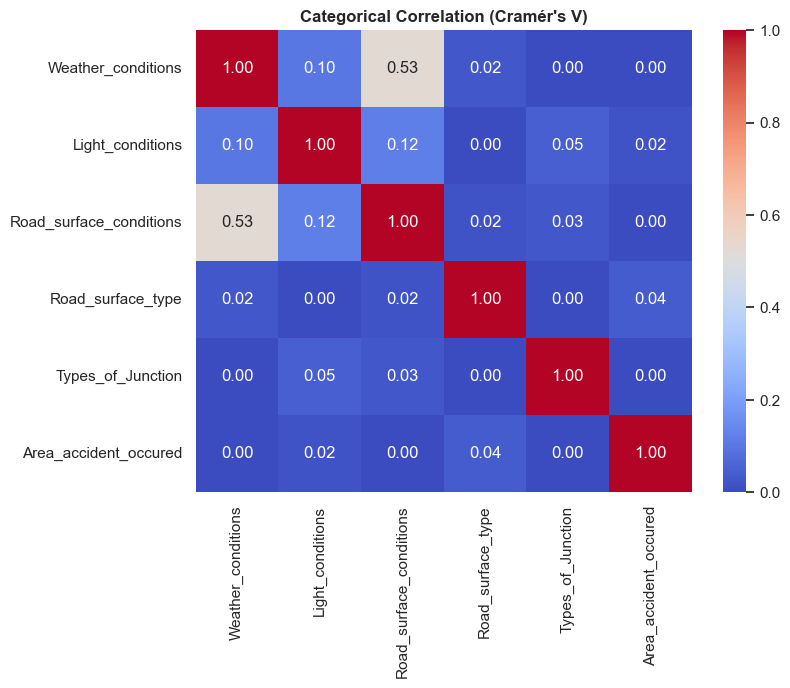

In [68]:
print("="*50)
print("STEP 7 & 9: CATEGORICAL CORRELATION (Cramér's V)")
print("="*50)

import scipy.stats as ss

# Function to calculate Cramér's V (correlation for categorical data)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    # Handle edge case where denominator might be 0
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select a subset of important categorical columns to check for redundancy
# We don't do all 30 at once to save compute time
cols_to_check = ['Weather_conditions', 'Light_conditions', 'Road_surface_conditions', 
                 'Road_surface_type', 'Types_of_Junction', 'Area_accident_occured']

# Build the correlation matrix
corr_matrix = pd.DataFrame(index=cols_to_check, columns=cols_to_check)
for col1 in cols_to_check:
    for col2 in cols_to_check:
        corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Convert to float for seaborn
corr_matrix = corr_matrix.astype(float)

# Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title("Categorical Correlation (Cramér's V)", fontweight='bold')
plt.show()

In [69]:
# The remaining columns with missing data
remaining_null_cols = [
    'Driving_experience', 
    'Type_of_vehicle', 
    'Owner_of_vehicle', 
    'Educational_level', 
    'Vehicle_driver_relation'
]

# Fill them with 'Unknown' so the model can treat 'missing' as its own category
for col in remaining_null_cols:
    df[col].fillna('Unknown', inplace=True)

print("Remaining nulls handled. Ready for the final checkpoint!")

Remaining nulls handled. Ready for the final checkpoint!


## Final Checkpoint

In [70]:
print("="*50)
print("FINAL DATA QUALITY CHECK & CHECKPOINT")
print("="*50)

# 1. Verify all missing values are handled
missing_counts = df.isnull().sum()
remaining_missing = missing_counts[missing_counts > 0]

if remaining_missing.empty:
    print("✅ All missing values have been successfully handled.")
else:
    print("❌ WARNING: Missing values still exist!")
    display(remaining_missing)

# 2. Verify data shape before saving
print(f"Final Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. Save the clean data to the processed folder
# Using index=False is critical so Pandas doesn't save the row numbers as a new, meaningless column
output_path = '../data/processed/road_data_cleaned.csv'

try:
    df.to_csv(output_path, index=False)
    print(f"✅ Cleaned dataset successfully saved to: {output_path}")
except Exception as e:
    print(f"❌ Error saving file: {e}")
    print("Make sure the '../data/processed/' directory exists!")

FINAL DATA QUALITY CHECK & CHECKPOINT
❌ WARNING: Missing values still exist!


Age_band_of_driver         1548
Sex_of_driver               178
Educational_level           841
Vehicle_driver_relation     593
Driving_experience          829
Type_of_vehicle             950
Owner_of_vehicle            482
Service_year_of_vehicle    6811
Defect_of_vehicle          4427
Area_accident_occured       261
Lanes_or_Medians            442
Road_allignment             142
Types_of_Junction          1078
Road_surface_type           172
Weather_conditions          292
Type_of_collision           169
Vehicle_movement            396
Casualty_class             4443
Sex_of_casualty            4443
Age_band_of_casualty       4443
Casualty_severity          4443
Work_of_casuality          3217
Fitness_of_casuality       2635
Cause_of_accident            25
dtype: int64

Final Dataset Shape: 12316 rows, 34 columns
✅ Cleaned dataset successfully saved to: ../data/processed/road_data_cleaned.csv


## EDA Plots

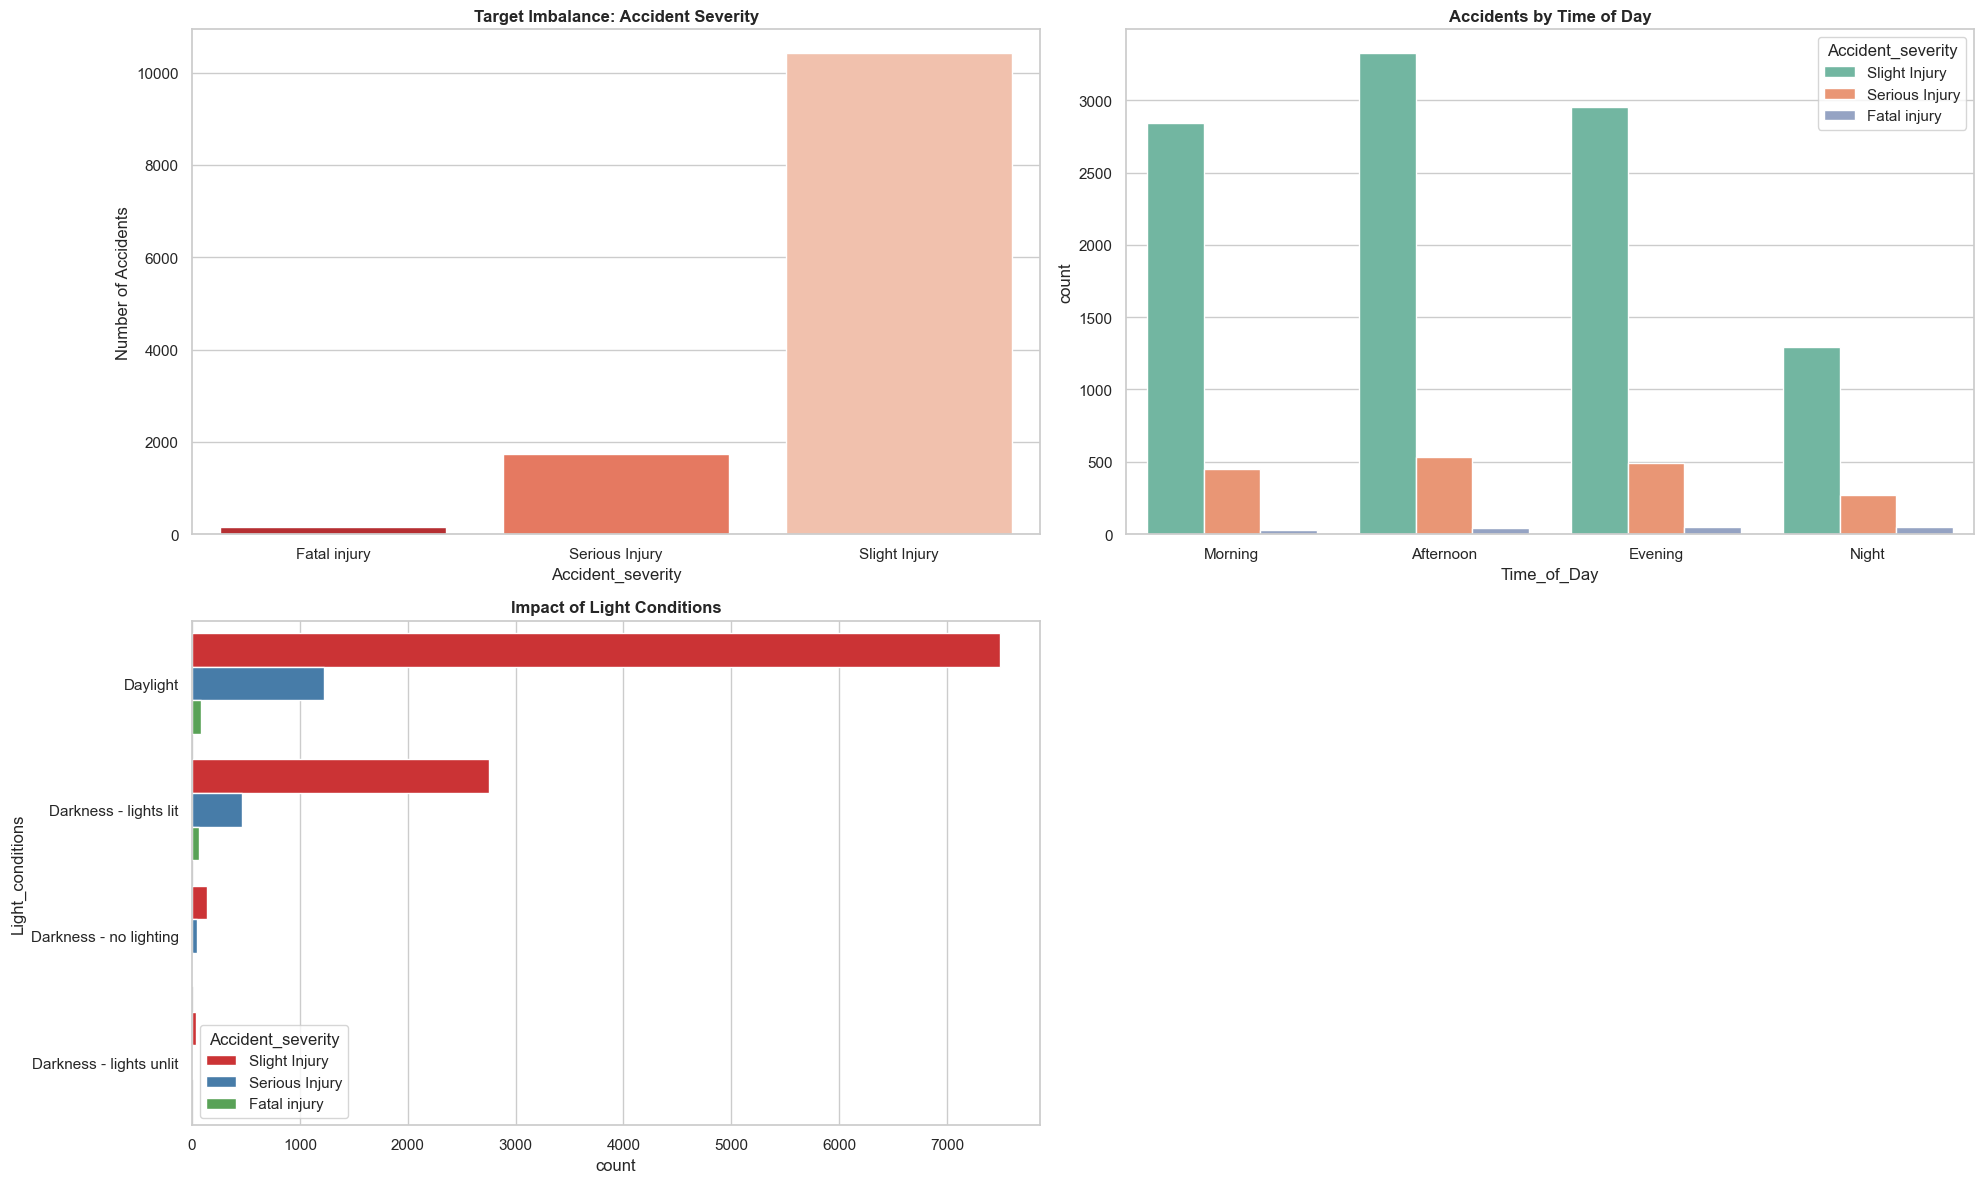

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1
sns.countplot(
    data=df, x='Accident_severity',
    ax=axes[0, 0],
    palette='Reds_r',
    order=['Fatal injury', 'Serious Injury', 'Slight Injury']
)
axes[0, 0].set_title('Target Imbalance: Accident Severity', fontweight='bold')
axes[0, 0].set_ylabel('Number of Accidents')

# Plot 2
sns.countplot(
    data=df, x='Time_of_Day', hue='Accident_severity',
    ax=axes[0, 1],
    palette='Set2',
    order=['Morning', 'Afternoon', 'Evening', 'Night']
)
axes[0, 1].set_title('Accidents by Time of Day', fontweight='bold')

# Plot 3
sns.countplot(
    data=df, y='Light_conditions', hue='Accident_severity',
    ax=axes[1, 0],
    palette='Set1'
)
axes[1, 0].set_title('Impact of Light Conditions', fontweight='bold')

# Remove empty subplot (bottom-right)
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

## Environmental Interactions

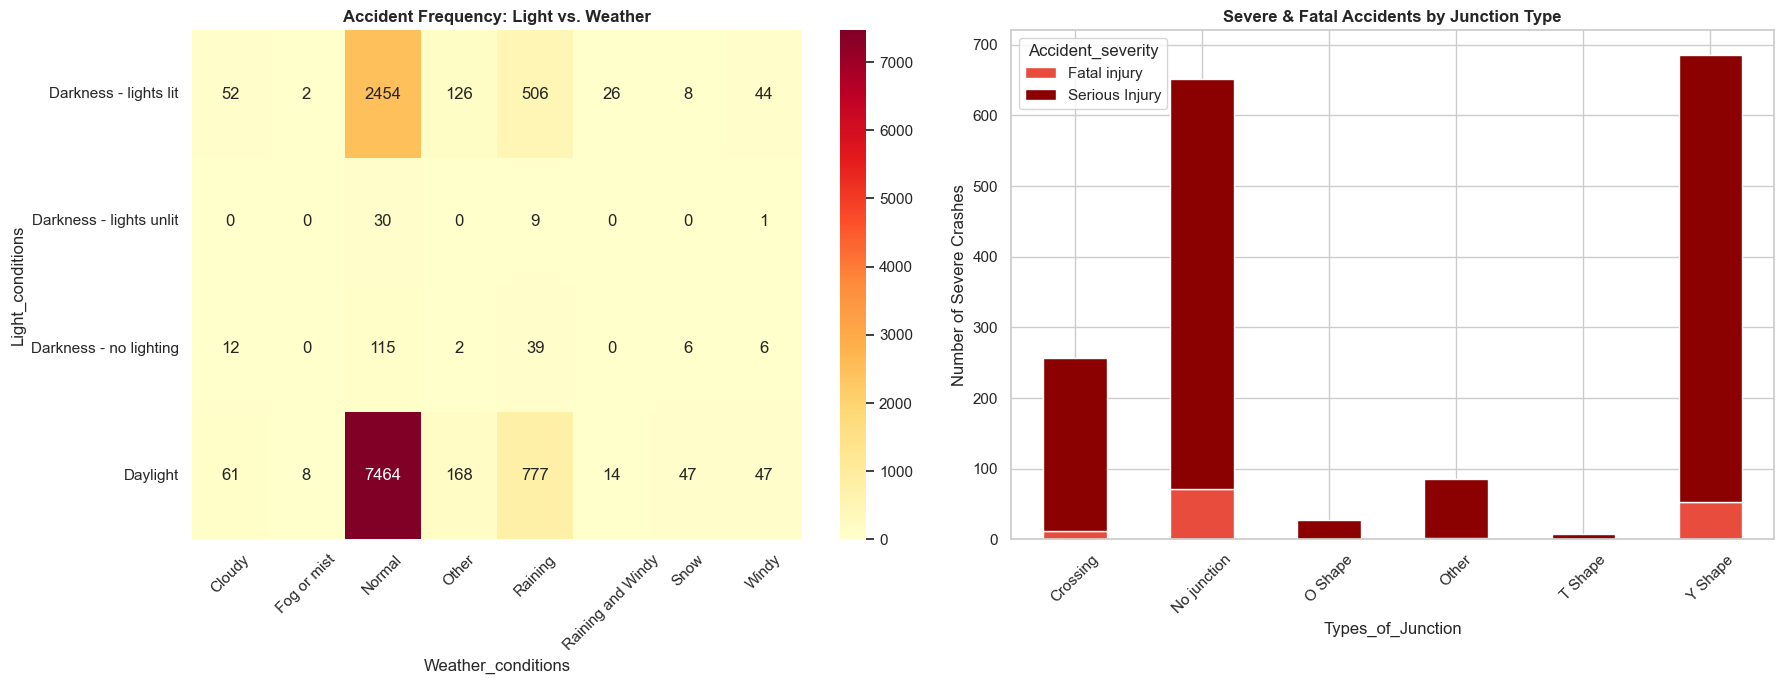

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap 1: Light Conditions vs. Weather Conditions
light_weather = pd.crosstab(df['Light_conditions'], df['Weather_conditions'])
sns.heatmap(light_weather, cmap='YlOrRd', annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Accident Frequency: Light vs. Weather', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap 2: Serious/Fatal Accidents by Junction Type
# Filter only for severe accidents to find infrastructure weaknesses
severe_mask = df['Accident_severity'].isin(['Serious Injury', 'Fatal injury'])
severe_accidents = df[severe_mask]

junction_severity = pd.crosstab(severe_accidents['Types_of_Junction'], severe_accidents['Accident_severity'])
junction_severity.plot(kind='bar', stacked=True, color=['#e74c3c', '#8b0000'], ax=axes[1])
axes[1].set_title('Severe & Fatal Accidents by Junction Type', fontweight='bold')
axes[1].set_ylabel('Number of Severe Crashes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Driver Behaviour and Demographics

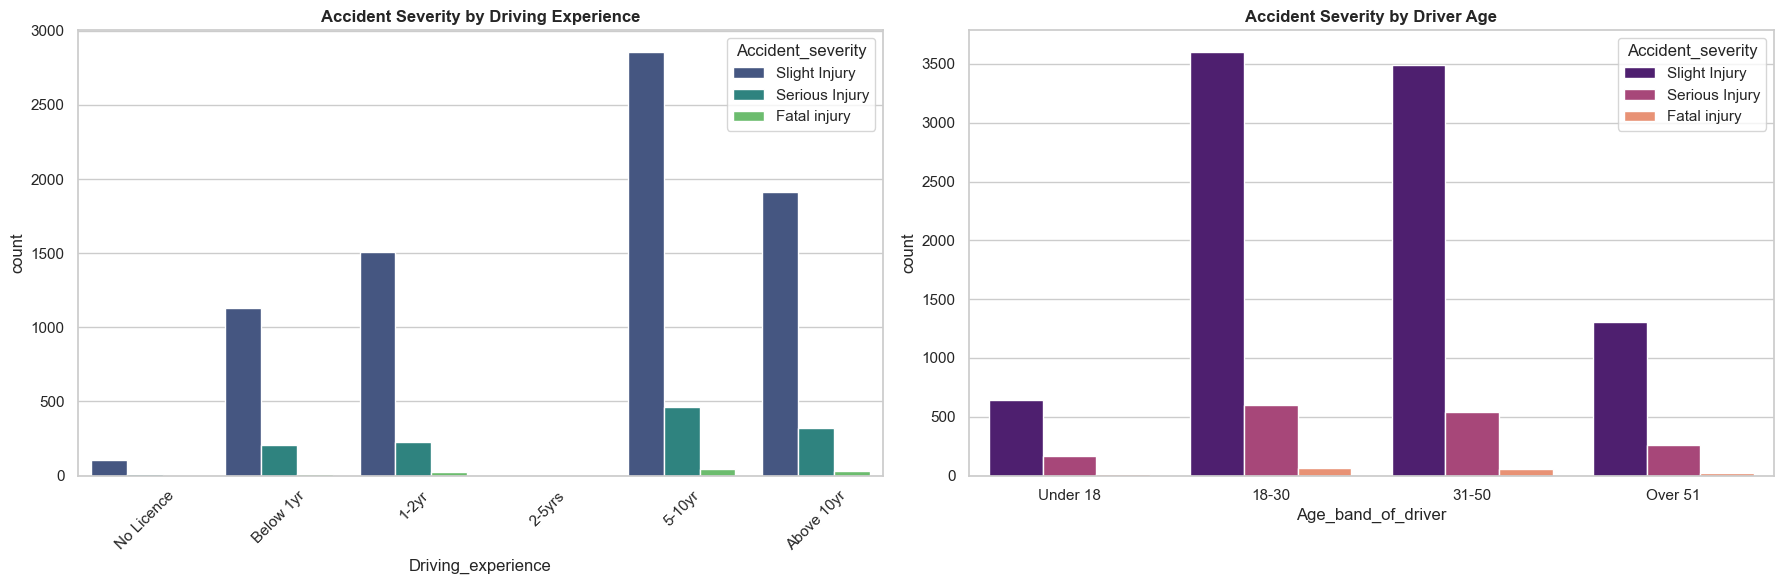

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Driving Experience vs. Accident Severity
sns.countplot(data=df, x='Driving_experience', hue='Accident_severity', ax=axes[0], palette='viridis',
              order=['No Licence', 'Below 1yr', '1-2yr', '2-5yrs', '5-10yr', 'Above 10yr'])
axes[0].set_title('Accident Severity by Driving Experience', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Age Band of Driver
sns.countplot(data=df, x='Age_band_of_driver', hue='Accident_severity', ax=axes[1], palette='magma',
              order=['Under 18', '18-30', '31-50', 'Over 51'])
axes[1].set_title('Accident Severity by Driver Age', fontweight='bold')

plt.tight_layout()
plt.show()

## Root Cause Analysis for Policy Makers


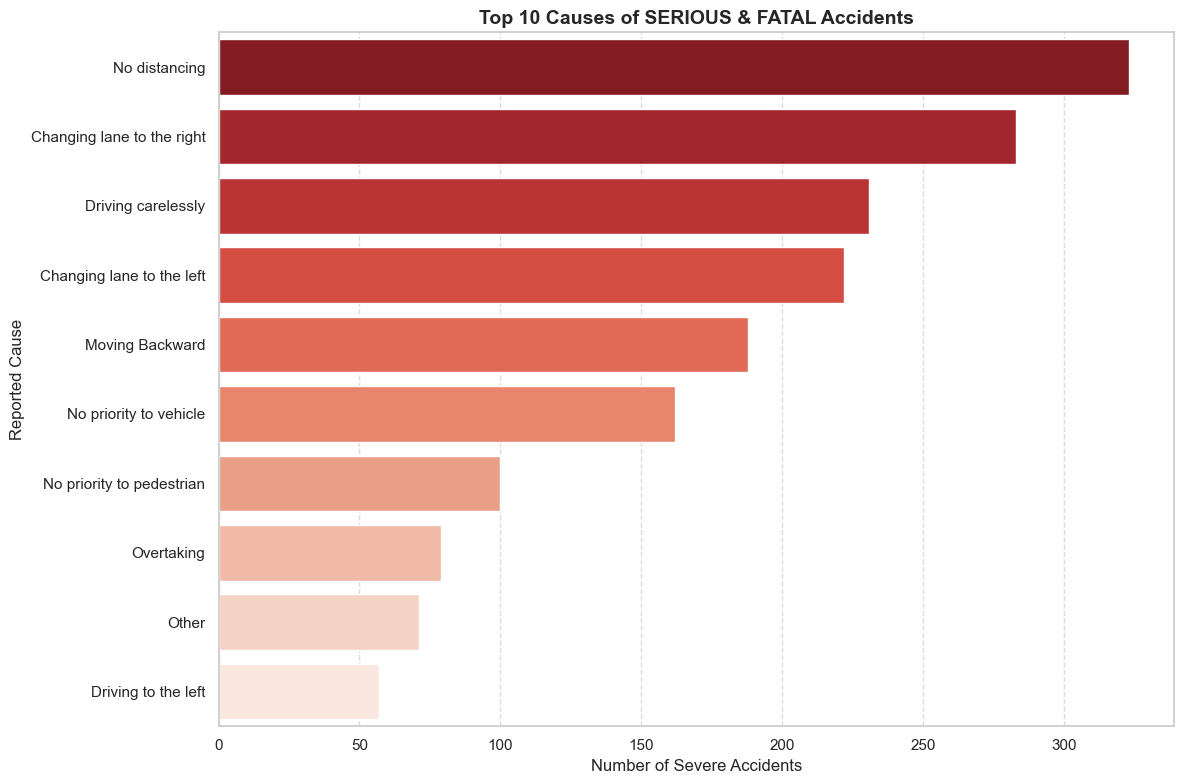

In [74]:
plt.figure(figsize=(12, 8))

# Get the top 10 causes for SEVERE accidents only
top_severe_causes = severe_accidents['Cause_of_accident'].value_counts().head(10)

sns.barplot(x=top_severe_causes.values, y=top_severe_causes.index, palette='Reds_r')
plt.title('Top 10 Causes of SERIOUS & FATAL Accidents', fontweight='bold', fontsize=14)
plt.xlabel('Number of Severe Accidents')
plt.ylabel('Reported Cause')

# Add a vertical grid for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()